## __`CS : Compressed Sensing of Images`__
 - ce notebook explore l’acquisition comprimée (compressed sensing) d’images naturelles,
 - en évaluant plusieurs modèles de parcimonie des coefficients dans une base d’ondelettes, 
 - afin d’améliorer la qualité de reconstruction à partir d’un nombre réduit de mesures.
La théorie du "compressed sensing" / "sparsity", revêt l’idée mathématique qui stipule que :  
 - l'on peut reconstruire un signal à partir de beaucoup moins de mesures que sa dimension, 
 - à condition qu’il soit parcimonieux ou sparse c-a-d que la plupart de ses coefficients sont nuls dans une base adaptée.
#### _`Sparsity:`_ 
$$\Large x = \Psi.m \text{ <=> } \Large m = \Psi^{-1}.x$$
- $x$ signal sparse parcimonieux dont la plupart des composantes sont nulles ou négligeables.
- $\Psi$ transforme le signal $m$ en représentation parcimonisante sparse $x$ (ondelettes, Fourier, etc,).
- $m\in R^N$ signal (image, son, etc.)
- $\Psi^{-1}$ opérateur inverse qui reconstruit $m$ à partir de $x$.

#### _`Cadre de base`_
On observe un **signal** $m \in \mathcal{R}^N$ `via des mesures linéaires` $y = A.m$ 
- N dimension du signal (longueur du vecteur ou nombre de pixels)
- M nombre de mesures (nombre de lignes de A)
- où $A \in \mathcal{R}^{M \times N}$ est une matrice de mesure et $M \ll N$.
- $y\in R^M$ vecteur de mesures 
On dit que le système est sous‑déterminé, car il existe une infinité de $m$ compatibles avec $y$.


#### _`Rôle de la parcimonie`_
La parcimonie permet de sélectionner, parmi toutes les solutions, la représentation la plus « rare » $x$ : 
- $\min_{x} \|x\|_0 \text{ sous la contrainte } y = A \Psi^{-1} x.$ 
Ce problème en $\ell_0$ est combinatoire, on le remplace par 
- $\min_{x} \|x\|_1\text{ sous } y = A \Psi^{-1} x$ qui est convexe, sous hypothèses appropriées sur $A$ (incohérence, RIP)

La minimisation en norme $\ell_1$ permet de retrouver la solution parcimonieuse, même lorsque $M \ll N$.
- l’astuce de CS est d’ajouter l’hypothèse de parcimonie sur le signal, 
- on suppose qu’il admet une représentation $x = \Psi.m$, dans une base ou dictionnaire $\Psi$, 
- $x$ est K‑parcimonieux, si le vecteur $x$ ne possède qu'un petit nombre $K$ de coefficients non nuls, 
- tel qu'écrit $x = \Psi.\alpha$ avec $\alpha$ ayant peu de coefficients significatifs dans une base $\Psi$.

#### `Intuition pour les images naturelles`
Pour une image $m$, on prend souvent $x = \Psi \alpha$ avec $\Psi$ base d’ondelettes, car :
- les images naturelles ont des coefficients d’ondelettes qui décroissent vite avec l’échelle.  
- elles sont bien approchées par un **petit nombre** de coefficients significatifs (bords, contours),
- donc $\alpha$ est parcimonieux ou compressible. 
`De ce fait l'on peut:`
1. Mesurer directement $y = A.m$ avec $M \ll N$.  
2. Reconstruire $\hat m$ en résolvant un problème de minimisation $\ell_1$ sur les coefficients ondelettes. 
##### __`Synthèse`__
On cherche à reconstruire un signal $x∈R^N$ à partir d’un nombre de mesures linéaires $M≪N$, données par $y=Ax$. 
_`La clé est l’hypothèse de parcimonie suppose que:`_ 
- $x$ est sparse ou compressible dans une base adaptée, c-a-d qu’il peut s’écrire $x=\Phi\alpha$ 
- avec un vecteur de coefficients $\alpha$ comportant peu de composantes significatives. 
- sous des hypothèses appropriées sur la matrice de mesure $A$ (incohérence, propriété de type RIP),
- on peut retrouver $x$ en résolvant un problème de minimisation de norme $\ell_1$ sur les coefficients $\alpha$, 
- permettant une reconstruction fidèle malgré un sous‑échantillonnage important.

In [1]:
import sys, os
import numpy as np
toolbox_parent = r"/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_IMGCMPT/TP23_Imagerie_Computationnelle"
sys.path.insert(0, toolbox_parent)

from nt_toolbox.general import *
from nt_toolbox.signal import *
import nt_toolbox as nt

%matplotlib inline
%load_ext autoreload
%autoreload 2

#### `Filtre "pass-bas" mesures linéaires`
`Utiliser les mesures d'un filtre "pass-bas" pour retirer les basses fréquences de l'image`.
 - les images naturelles ne sont pas seulement parcimonieuses dans le domaine des ondelettes. 
 - elles présentent également une décroissance rapide des coefficients au fil des échelles. 
 - la graine d'ondelette grossières (passe-bas) concentrent une grande partie de l’énergie de l’image.
 - il est donc pertinent de mesurer directement les coefficients "pass-bas"
`Opérationnellement : `
 - cela revient à appliquer une décomposition en ondelettes, 
 - à extraire les coefficients d’approximation de niveau grossier, 
 - on met à zéro les coefficients $C_A$ d'approximation issus du passe‑bas.
 - puis à annuler ces coefficients lors de la reconstruction pour obtenir une image sans basses fréquences. » 

Maintenant nous chargeons une image $m \in \mathcal{R}^{n^2}$ de $n \times n$ pixels.

(512, 512)


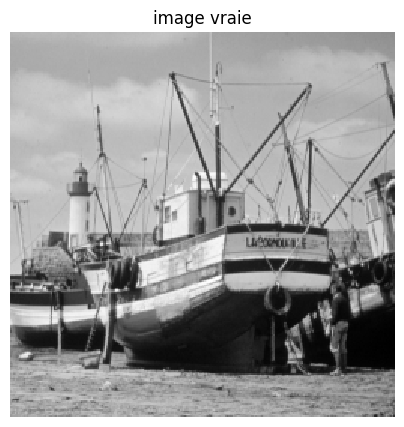

In [2]:
path= '/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_IMGCMPT/TP23_Imagerie_Computationnelle/'
name = path + 'nt_toolbox/data/boat.bmp'
n = 512

f0 = load_image(name)          # f0.shape = (256, 256)
f0 = (f0 - f0.min()) / (f0.max() - f0.min() + 1e-12)
print(f0.shape)

from skimage.transform import rescale

f0= rescale(f0, scale=0.5, anti_aliasing=True)   # par ex. moitié moins grand
plt.figure(figsize=(5, 5))
imageplot(clamp(f0),'image vraie')

`Raccourci pour les transformés en ondelettes` $\{ \langle f, \Psi_m \rangle \}_m$
- Nous calculons la transformée jusqu'à l'échelle $J$ de sorte que seuls les sous-bandes $k_0$ sont transformées.
- Les coefficients d’ondelettes sont des produits scalaires entre le signal et des “briques” de base.

Définition de $P$ opérateur de projection passe‑bas sur l’espace d’approximation d’échelle J en fonction des coefficients d’approximation ondelettes $\Phi_{J,k}$ :
-  $P_f=\sum_k⟨f,\Phi_{J,k} ⟩\Phi_{J,k})$ et son lien avec ton code wavedec2 

Mathématiquement, nous avons une décomposition du type : 
- $\large f(t) = \sum_{k} cA_J[k]\,\phi_{J,k}(t) + \sum_{j=1}^{J} \sum_{k} cD_j[k]\,\psi_{j,k}(t)$

  - où $\Phi_{J,k}$ sont les fonctions d’échelle et $\Psi_{j,k}$ les ondelettes.
  - le premier bloc concatèné correspond à cA_J (approximation grossière).
  - les blocs suivants sont cD_1, cD_2, ..., cD_J (détails de plus en plus grossiers suivant l'ordre).
  - sert à fixer la plus petite échelle (ou niveau minimal) de la transformée en ondelettes, 
  - c’est‑à‑dire jusqu’où on descend dans les décompositions en résolution.

`Que représente un coefficient`
Pour chaque échelle J et la position k :
- $\Phi_{J,k}(t)$ : une fonction d’échelle (low-pass) centrée près de la position k, à l’échelle grossière J.
- $\Psi_{j,k}(t)$ : une ondelette (petite oscillation localisée) à l’échelle J et position k.

Avec Discrete Wavelet Transform 1D, les coefficients [cA_J, cD_J, cD_{J-1}, ..., cD_1] obtenus ont pour signification : 
`cA_J :` 
- coefficients d’approximation au niveau le plus grossier J. 
- ce sont les projections du signal sur les fonctions d’échelle (low-pass), 
- donc le contenu “lent”, les grandes structures / tendance globale.

`cD_j :` 
- coefficients de détail au niveau j. 
- ce sont les projections sur les ondelettes à l’échelle $2^j$, 
- donc le contenu “rapide” autour de cette échelle, variations locales, détails, singularités.

Intuition par niveau :
- `cD_1` : détails les plus fins (hautes fréquences, bruit, petits bords).
- `cD_2` : un peu plus grossier, etc.
- `cD_J` : détails relativement grossiers, structures un peu plus larges.
- `cA_J` : ce qui reste après avoir filtré tous ces détails, une version très lissée du signal.

#### `Transformée en ondelettes discrètes 2D directe et inverse` 

In [3]:
import pywt
import numpy as np

# perform_direct_wavelet_transf transformée directe est un opérateur qui prend une image f 
# et renvoie ses coefficients d’ondelettes.
def perform_direct_wavelet_transf(f,n,k0,wavelet):
    # par ex., à adapter à ce que fait options.wavelet
    w = pywt.Wavelet(wavelet)
    # 2D image : f is 2D array
    coeffs_ti_2d = pywt.wavedec2(f, wavelet=w, level=k0, mode='periodization')
    return coeffs_ti_2d

# perform_inverse_wavelet_transf l’opérateur inverse qui à partir des coefficients d’ondelettes, 
# reconstruit l’image, en appelant.
def perform_inverse_wavelet_transf(coeffs,wavelet):
    # 2D image : f is 2D array
    w = pywt.Wavelet(wavelet)
    f_rec = pywt.waverec2(coeffs, wavelet=w, mode='periodization')
    return f_rec

`Calculer la transformée en ondelette.`

In [4]:
wavelet='sym8'
k0=2

coeffs_ti_2d = perform_direct_wavelet_transf(f0,n,k0,wavelet)# [cA_J, (cH_J,cV_J,cD_J), ..., (cH_1,cV_1,cD_1)]
# Approximation au niveau le plus grossier
cA = coeffs_ti_2d[0]
print(f"cA_J : {cA.shape}, len(coeffs_ti_2d[1:] : {len(coeffs_ti_2d[1:])}), len(coeffs_ti_2d) : {len(coeffs_ti_2d)}\n")
# Détails : du niveau J jusqu'au niveau 1
for j, (cH, cV, cD) in enumerate(coeffs_ti_2d[1:], start=1):
    level = len(coeffs_ti_2d) - j   # juste pour numéroter J, J-1, ..., 1
    print(f"{j} Level {level}: cH_{level} {cH.shape}, cV_{level} {cV.shape}, cD_{level} {cD.shape}")

cA_J : (64, 64), len(coeffs_ti_2d[1:] : 2), len(coeffs_ti_2d) : 3

1 Level 2: cH_2 (64, 64), cV_2 (64, 64), cD_2 (64, 64)
2 Level 1: cH_1 (128, 128), cV_1 (128, 128), cD_1 (128, 128)


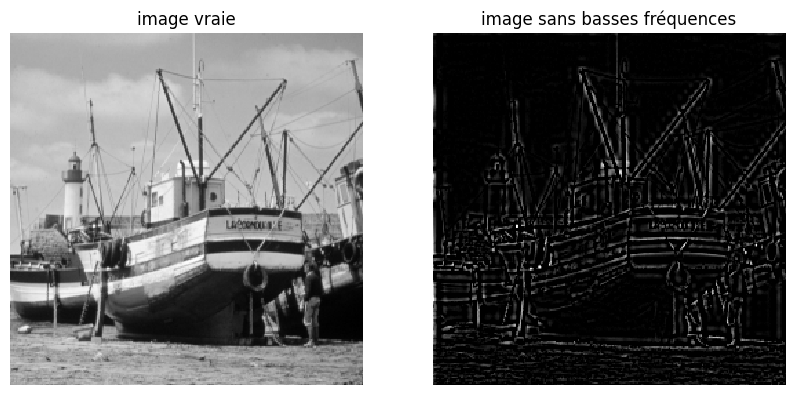

In [5]:
# Mise à zéro de cA (basses fréquences)
cA, details = coeffs_ti_2d[0], coeffs_ti_2d[1:]
cA_zero = np.zeros_like(cA)
coeffs_high = [cA_zero] + list(details)
f_vec = perform_inverse_wavelet_transf(coeffs_high,wavelet)
plt.figure(figsize=(10, 10))
imageplot(clamp(f0),'image vraie',[1,2,1])
imageplot(clamp(f_vec),'image sans basses fréquences',[1,2,2])

- on décompose l’image par ondelettes, on annule les coefficients d’approximation $cA\_J$ (passe‑bas) 
- on reconstruit à partir des seuls coefficients de détail. 
- le résultat est une image où la composante basse fréquence a été retirée, 
- ne laissant visibles que les structures de haute fréquence (contours, textures).

#### __`Exercice 1`__
Construire une approximation basse fréquence $∣f_{low}∣$ 
- Ne conserver que les coefficients passe‑bas, au nombre de $P=2^{2^J} =(n/k_0)^2$ : 
  - image est de taille $n×n$.
  - on travaille avec une décomposition ondelette 2D à $J=log2(n)−k0$ niveaux.
  - au niveau le plus grossier, le bloc basse fréquence (cA_J) est de taille $(n/2^{k_0})×(n/2^{k_0})$.
  - si on note $2^{k_0}=k_0$ => $(n/2^{k_0})×(n/2^{k_0}) \equiv (n/{k_0})^2$ => $P=2^{2^J} =(n/k_0)^2$
  - P correspond au nombre de coefficients passe‑bas utilisés pour construire $f_{low}$

P : 16384.0 cA.shape (64, 64)


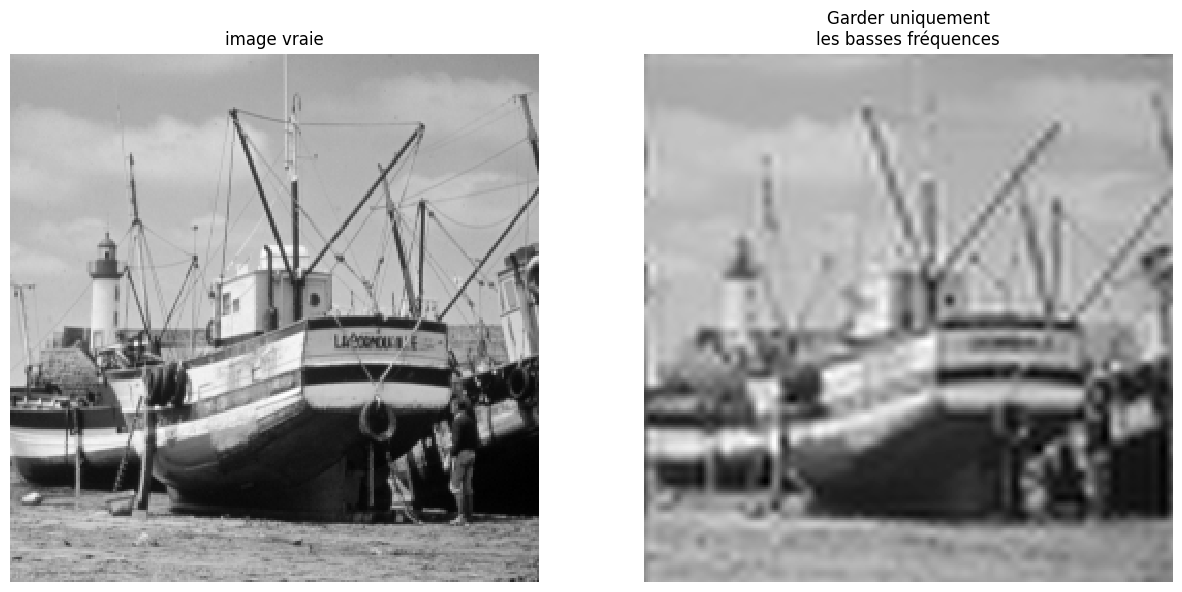

In [37]:
details_zero = [(np.zeros_like(cH),
                 np.zeros_like(cV),
                 np.zeros_like(cD)) for (cH, cV, cD) in details]
P = (n/2**k0)**2
print(f"P : {P} cA.shape {coeffs_ti_2d[0].shape}")
coeffs_low = [cA] + details_zero
f_low = perform_inverse_wavelet_transf(coeffs_low,wavelet)
plt.figure(figsize=(15, 15))
imageplot(clamp(f0),'image vraie',[1,2,1])
imageplot(clamp(f_low),f'Garder uniquement\nles basses fréquences',[1,2,2])


### `Mesures orthogonales aléatoires`.
- Considérons un opérateur "compressed sensing" qui correspond à une projection orthogonal randomisée.
- Extraire les coefficients d'ondelettes haute-fréquences $x_0 = \{ \langle f, \psi_m \rangle \}_{m \in I_0}$.
   - A est un masque $n×n$ rempli de 1.
   - on met à 0 le bloc supérieur gauche de taille $2^J×2^J$
   - A == 0 = zone low-pass, 
   - A == 1 = zone high-pass

<table border="1" style="border-collapse:collapse; text-align:center; font-family:monospace;">
  <tr>
    <td style="width:30px; height:30px;">0<br><small>LL</small></td>
    <td style="width:30px; height:30px;">1<br><small>LH</small></td>
    <td rowspan="2" style="width:60px; height:60px;">1<br><small>LH</small></td>
  </tr>
  <tr>
    <td style="width:30px; height:30px;">1<br><small>HL</small></td>
    <td style="width:30px; height:30px;">1<br><small>HH</small></td>
  </tr>
  <tr>
    <td colspan="2" style="width:60px; height:60px;">1<br><small>HL</small></td>
    <td style="width:60px; height:60px;">1<br><small>HH</small></td>
  </tr>
</table>
<div>
</div>

| Zone                                           | Valeur dans A | Rôle                             |
| ---------------------------------------------- | ------------- | -------------------------------- |
| Bloc $2^J \times 2^J$ en haut à gauche | 0             | Low-pass (exclus de $I_0$)    |
| Tout le reste                                  | 1             | High-pass (inclus dans $I_0​$) |

Extrait du vecteur de coefficients d'ondelettes les coefficients haute-fréquence $x_0={⟨f,ψ.m⟩}m∈I_0$
- reconstruire l'image de coefficients (n x n) d'un coup
- fw_img — Recolle toutes les sous-bandes en une seule image 2D
- slices — Retourne les positions de chaque sous-bande dans fw_img

In [52]:
# Reconstruire l'image de coefficients (n x n) d'un coup
# fw_img — Recolle toutes les sous-bandes en une seule image 2D
# slices — Retourne les positions de chaque sous-bande dans fw_img

J = int(np.log2(n) - k0)

coeffs_ti_2d = perform_direct_wavelet_transf(f0,n,k0,wavelet)
fw_img, slices = pywt.coeffs_to_array(coeffs_ti_2d)

A = np.ones((fw_img.shape))  
A[0:2**J, 0:2**J] = 0
# retourne les indices de la matrice ou se trouvent les coefficients hautes fréquences
I0 = np.where(A.flatten()==1)[0]
print(f"Nombre de niveaux : {len(coeffs_ti_2d) - 1}, fw_img.shape : {fw_img.shape}, {fw_img.shape[0]*fw_img.shape[0]} , A.shape : {A.shape}, I0.shape : {I0.shape}")
x0 = fw_img.flatten()[I0]
print(f"Le nombre de coefficients est de : {len(x0)}")

Nombre de niveaux : 2, fw_img.shape : (256, 256), 65536 , A.shape : (256, 256), I0.shape : (49152,)
Le nombre de coefficients est de : 49152


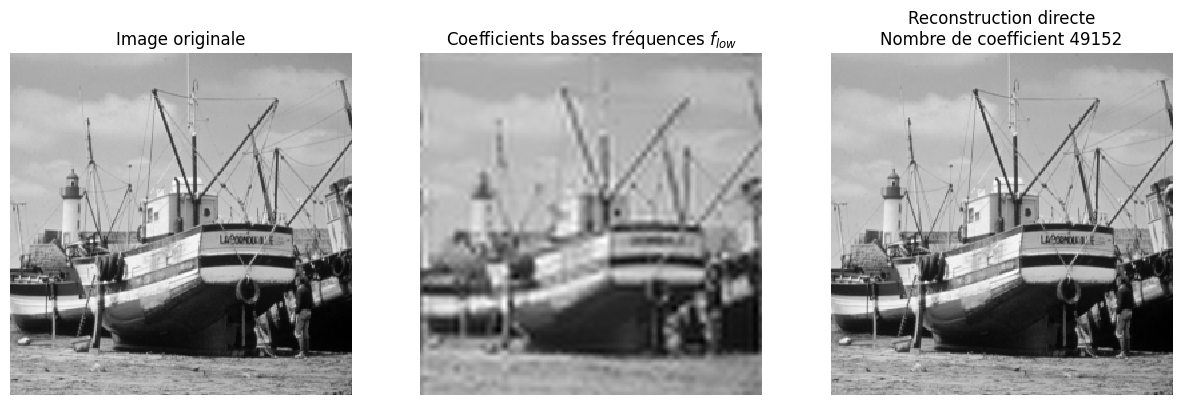

In [53]:
fw_rec_2d = fw_img.flatten().reshape(fw_img.shape)

# Reconstruire depuis les coefficients d'ondelettes
coeffs_rec = pywt.array_to_coeffs(fw_rec_2d, slices, output_format='wavedec2')
f_rec = pywt.waverec2(coeffs_rec, wavelet=wavelet, mode='periodization')

# Affichage
plt.figure(figsize=(15, 5))
imageplot(clamp(f0),    'Image originale',             [1, 3, 1])
imageplot(clamp(f_low), 'Coefficients basses fréquences $f_{low}$', [1, 3, 2])
imageplot(clamp(f_rec), f'Reconstruction directe\nNombre de coefficient {len(x0)}', [1, 3, 3])
plt.show()

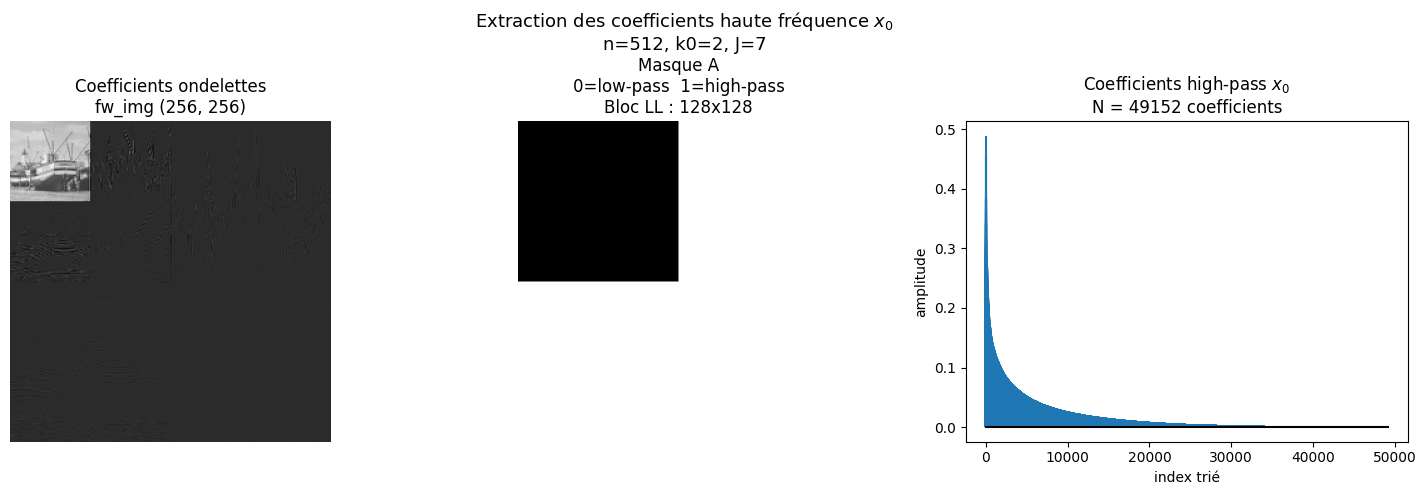

fw_img.shape : (256, 256)
Bloc LL      : (128 x 128) = 16384 coefficients low-pass
N = len(x0)  : 49152 coefficients high-pass


In [54]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Image de coefficients d'ondelettes
axes[0].imshow(fw_img, cmap='gray')
axes[0].set_title(f'Coefficients ondelettes\nfw_img {fw_img.shape}')
axes[0].axis('off')

# 2. Masque A (zone basse fréquence = noir, haute fréquence = blanc)
axes[1].imshow(A, cmap='gray')
axes[1].set_title(f'Masque A\n0=low-pass  1=high-pass\nBloc LL : {2**J}x{2**J}')
axes[1].axis('off')

# 3. Coefficients haute fréquence x0 (triés par amplitude)
axes[2].stem(np.sort(np.abs(x0))[::-1], markerfmt=' ', linefmt='C0-', basefmt='k-')
axes[2].set_title(f'Coefficients high-pass $x_0$\nN = {len(x0)} coefficients')
axes[2].set_xlabel('index trié')
axes[2].set_ylabel('amplitude')

plt.suptitle(f'Extraction des coefficients haute fréquence $x_0$\n' f'n={n}, k0={k0}, J={J}', fontsize=13)
plt.tight_layout()
plt.show()

print(f"fw_img.shape : {fw_img.shape}")
print(f"Bloc LL      : ({2**J} x {2**J}) = {4**J} coefficients low-pass")
print(f"N = len(x0)  : {len(x0)} coefficients high-pass")

`Nombre de mesures basses fréquences:` $ P_0 = 2^{2J}=(n/2^{k_0})^2 $

In [55]:
P0 = (n/2**k0)**2
print(f"Le nombre de de mesures basse fréquence : {P0}")

Le nombre de de mesures basse fréquence : 16384.0


`Nombre de mesures CS = Compressed Sensing (acquisition comprimée ou mesure comprimée)`
__Idée principale__
- En traitement du signal classique (théorème de Shannon-Nyquist), 
- il faut au moins autant de mesures que de coefficients pour reconstruire un signal : $P≥N$
_`Le Compressed Sensing dit`_ : 
- si le signal est parcimonieux (sparse), 
- c'est-à-dire que la plupart de ses coefficients sont nuls ou quasi-nuls, 
- alors on peut le reconstruire avec beaucoup moins de mesures : $P≪N$

In [56]:
P = 4 * P0
print(f"Le nombre de mesures CS : {P}")

Le nombre de mesures CS : 65536.0


`Générer les operateurs de permutations aléatoires` 
 - $S_1,S_2 : \mathcal{R}^N \rightarrow \mathcal{R}^N$ tel que $S_k(x)_i = x_{\sigma_k(i)}$ où $ \sigma_k \in \Sigma_N $ 
- soit une permutation aléatoire $\{1,\ldots,N\}$.

In [57]:
N = len(x0)   # 15360

# Deux permutations aléatoires sigma_1 et sigma_2
sigma1 = np.random.permutation(N)   # σ_1
sigma2 = np.random.permutation(N)   # σ_2

# Opérateurs directs
S  = lambda x,sigma: x[sigma]

# Opérateurs S_1 et S_2 appliqués à x0
S1_x0 = S(x0,sigma1)
S2_x0 = S(x0,sigma2)

`Opérateurs adjoints ou inverses` 
 - $S_1^*,S_2^*$ (notés |$S_1^S, S_2^S|$) 
 - correspondant à la permutation inverse $\sigma_k^*$ tel que  $\sigma_k^* \circ \sigma_k(i)=i$.

In [58]:
# Permutations inverses (adjoints)
sigma1S = np.zeros(N, dtype=int)
sigma1S[sigma1] = np.arange(N)

sigma2S = np.zeros(N, dtype=int)
sigma2S[sigma2] = np.arange(N)

# Opérateurs inverses (adjoints)
Sinv = lambda x,sigS: x[sigS]

# Vérification S1* ∘ S1 = identité
print(np.allclose(Sinv(S(x0, sigma1), sigma1S), x0))   # True
print(np.allclose(Sinv(S(x0, sigma2), sigma2S), x0))   # True

True
True


x (vecteur N coefficients high-pass)
    ↓  S1 : permutation aléatoire σ1
S1(x)
    ↓  C : transformée DCT
C(S1(x))
    ↓  S2 : permutation aléatoire σ2
S2(C(S1(x)))
    ↓  ↓_P : garder seulement les P premières entrées
y = Φx  (vecteur de P mesures)

`Considérons l'opérateur CS Compressed Sensing (acquisition comprimée ou mesure comprimée)` 
 - $\Phi:\mathcal{R}^N \rightarrow \mathcal{R}^P $ 
`CS correspond à une projection sur des atomes aléatoires :` 
 - $ (\Phi x)_i = \langle{x}{\Phi_{\sigma_2(i)}}\rangle $ 
   - ou $ \Phi_i $ est une base orthogonale mélangée (scrambled) : $ \Phi_i(x) = c_i( \sigma_1(x) ) $
   - où $\{ c_i \}_i$ est la base orthogonale DCT (Transformée en Cosinus Discrète).
`Ceci peut s'écrire sous la forme compacte d'opérateur :` 
 - $ \Phi x = ( S_2 \circ C \circ S_1 (x) ) \downarrow_P $
   - où $S_1,S_2$ sont les opérateurs de permutation, 
   - et $\downarrow_P$ sélectionne les $P$ premières entrées du vecteur.

Phi(x) = dP( S2( C( S1(x) ) ) )
                         ↓
      S1(x) : permutation σ1
                         ↓
      C(…)  : DCT orthogonale
                         ↓
      S2(…) : permutation σ2
                         ↓
      dP(…) : garder les P premiers  →  y ∈ R^P

In [59]:
from scipy.fft import dct, idct

P = N // 4   # nombre de mesures
print(f" N : {N} P : {P}")
# DCT orthogonale et son inverse
C     = lambda x: dct(x, norm='ortho')  # transformée en cosinus discrete dans une base orthogonale
Cinv  = lambda x: idct(x, norm='ortho') # transformée en cosinus discrete inverse dans une base orthogonale
# Sous-échantillonnage ↓_P : garder les P premières entrées
dP    = lambda x: x[:P]
# Opérateur Φ : R^N → R^P
Phi   = lambda x: dP(S(C(S(x0, sigma1)),sigma2))

 N : 49152 P : 12288


In [60]:
y = Phi(x0)
print(f"x0.shape     : {x0.shape}")       # (N,)  = (61440,)
print(f"y.shape      : {y.shape}")        # (P,)  = (15360,)

x0.shape     : (49152,)
y.shape      : (12288,)


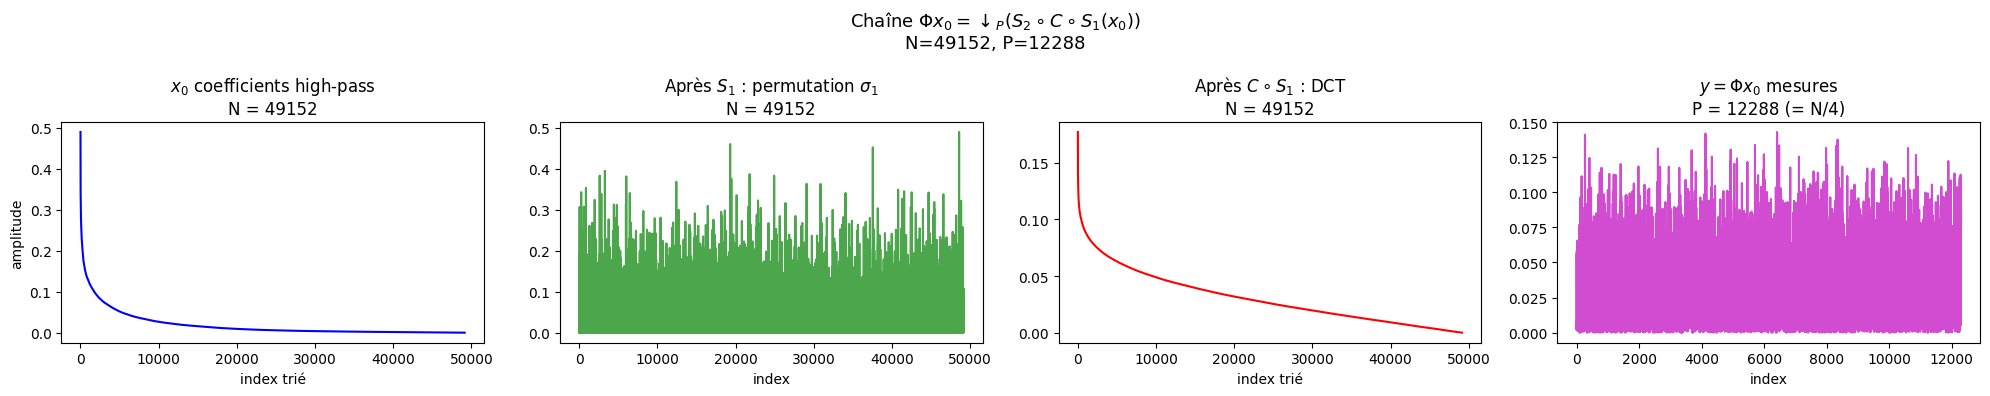

x0.shape : (49152,)
y.shape  : (12288,)


In [61]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# 1. x0 : coefficients high-pass originaux
axes[0].plot(np.sort(np.abs(x0))[::-1], 'b-')
axes[0].set_title(f'$x_0$ coefficients high-pass\nN = {N}')
axes[0].set_xlabel('index trié')
axes[0].set_ylabel('amplitude')

# 2. Après S1 : permutation sigma1
S1_x0 = S(x0, sigma1)
axes[1].plot(np.abs(S1_x0), 'g-', alpha=0.7)
axes[1].set_title(f'Après $S_1$ : permutation $\\sigma_1$\nN = {N}')
axes[1].set_xlabel('index')

# 3. Après C∘S1 : DCT
CS1_x0 = C(S1_x0)
axes[2].plot(np.sort(np.abs(CS1_x0))[::-1], 'r-')
axes[2].set_title(f'Après $C \\circ S_1$ : DCT\nN = {N}')
axes[2].set_xlabel('index trié')

# 4. y = Φx0 : mesures finales après S2 et ↓_P
axes[3].plot(np.abs(y), 'm-', alpha=0.7)
axes[3].set_title(f'$y = \\Phi x_0$ mesures\nP = {P} (= N/4)')
axes[3].set_xlabel('index')

plt.suptitle(f'Chaîne $\\Phi x_0 = \\downarrow_P(S_2 \\circ C \\circ S_1(x_0))$\n'
             f'N={N}, P={P}', fontsize=13)
plt.tight_layout()
plt.show()

print(f"x0.shape : {x0.shape}")   # (N,)
print(f"y.shape  : {y.shape}")    # (P,)

L'opérateur adjoint est : $ \Phi^* x = S_1^* \circ C^* \circ S_2^* (x\uparrow_P) $ où $\uparrow_P$ ajoute $N-P$ zéros à la fin d'un vecteur et 
 - $C^*$ est la transformée cosinus discrète inverse.

In [68]:
# Φ* : R^P → R^N
uparrow = lambda x,N,P: np.concatenate([x, np.zeros(N - P)])
PhiS  = lambda x,N,P: Sinv(Cinv(Sinv(uparrow(x,N,P), sigma2S)),sigma1S)

Effectuer les mesures de compressed sensing Perform CS (sans bruitage).

In [69]:
phiS = PhiS(Phi(x0),N,P)
print(f"phiS.shape : {phiS.shape},\nz : {phiS}")

phiS.shape : (49152,),
z : [-0.02033817  0.00928398  0.02800939 ... -0.00057017 -0.02489622
  0.03324421]


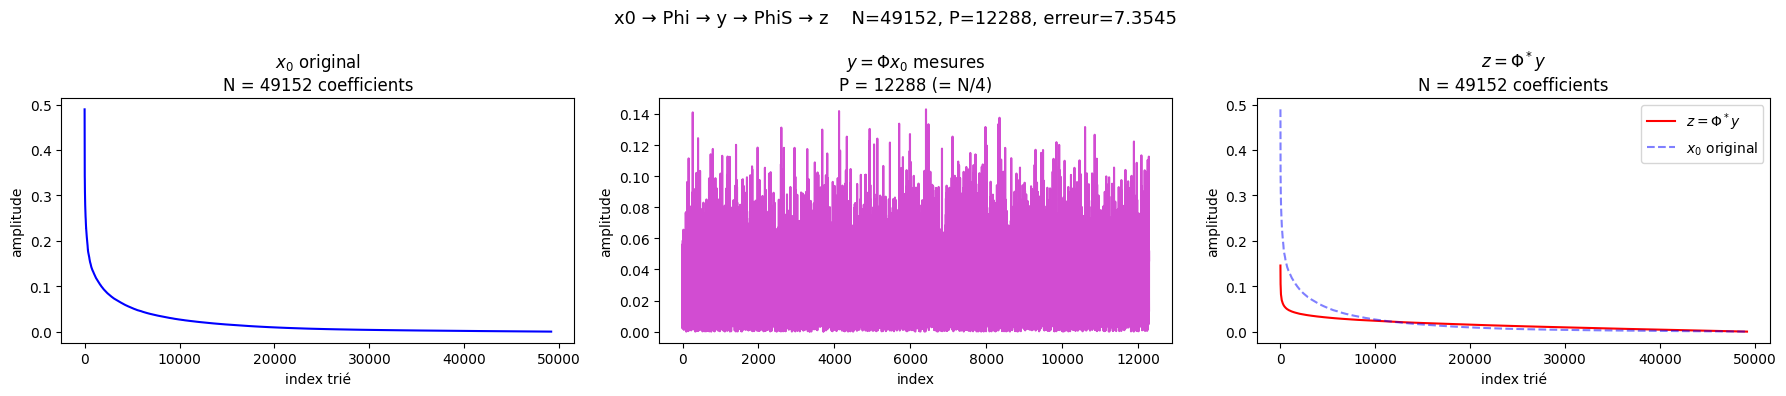

x0.shape : (49152,)
y.shape  : (12288,)
z.shape  : (49152,)
||z - x0||        : 7.354490
||x0||            : 8.507889
erreur relative   : 0.864432


In [70]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 1. x0 original
axes[0].plot(np.sort(np.abs(x0))[::-1], 'b-')
axes[0].set_title(f'$x_0$ original\nN = {N} coefficients')
axes[0].set_xlabel('index trié')
axes[0].set_ylabel('amplitude')

# 2. y = Φx0 : mesures
axes[1].plot(np.abs(y), 'm-', alpha=0.7)
axes[1].set_title(f'$y = \\Phi x_0$ mesures\nP = {P} (= N/4)')
axes[1].set_xlabel('index')
axes[1].set_ylabel('amplitude')

# 3. z = Φ*y : reconstruction
axes[2].plot(np.sort(np.abs(z))[::-1], 'r-', label='$z = \\Phi^* y$')
axes[2].plot(np.sort(np.abs(x0))[::-1], 'b--', alpha=0.5, label='$x_0$ original')
axes[2].set_title(f'$z = \\Phi^* y$\nN = {N} coefficients')
axes[2].set_xlabel('index trié')
axes[2].set_ylabel('amplitude')
axes[2].legend()

# ← suptitle simplifié sans \xrightarrow
erreur = np.linalg.norm(z - x0)
plt.suptitle(f'x0 → Phi → y → PhiS → z    N={N}, P={P}, erreur={erreur:.4f}',
             fontsize=13)
plt.tight_layout()
plt.show()

# Vérification numérique
print(f"x0.shape : {x0.shape}")
print(f"y.shape  : {y.shape}")
print(f"z.shape  : {z.shape}")
print(f"||z - x0||        : {np.linalg.norm(z - x0):.6f}")
print(f"||x0||            : {np.linalg.norm(x0):.6f}")
print(f"erreur relative   : {np.linalg.norm(z - x0) / np.linalg.norm(x0):.6f}")

#### __`Exercice 2`__
Reconstruire une image utilisant la pseudo inverse : $\Phi^+ y =\Phi^* y$
Cette égalité $\Phi^+ = \Phi^*$ est valable car $\Phi$ est construit à partir d'opérations orthogonales (permutations + DCT orthogonale), 
 - donc :$ΦΦ^∗ = I_P ⇒ Φ^+ = Φ^∗$

x_rec.shape : (49152,)


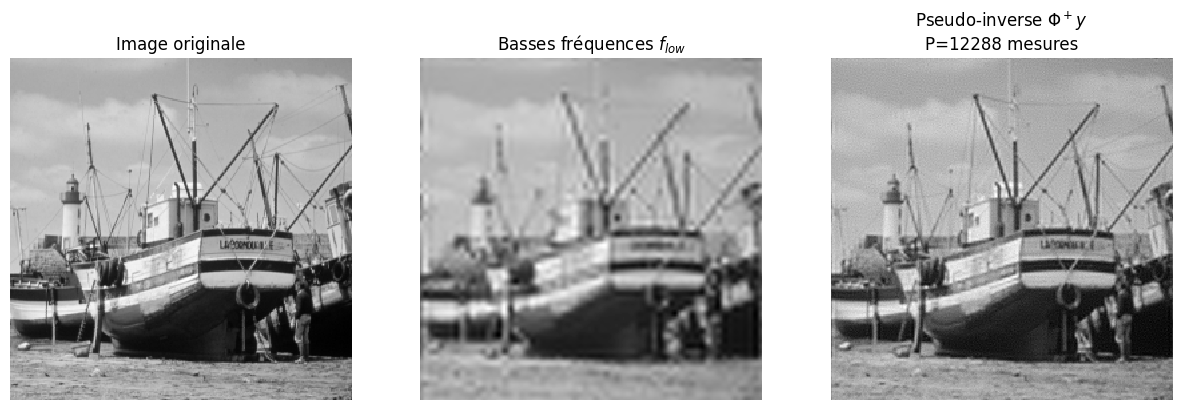

In [72]:
y = Phi(x0)
x_rec = PhiS(y,N,P)

print(f"x_rec.shape : {x_rec.shape}")  # (N,)

J = int(np.log2(n) - k0)
A = np.ones((fw_img.shape))  
A[0:2**J, 0:2**J] = 0
# retourne les indices de la matrice ou se trouvent les coefficients hautes fréquences
I0 = np.where(A.flatten()==1)[0]

# 3. Reconstruire l'image complète
fw_rec = fw_img.flatten().copy()
fw_rec[I0] = x_rec                   # replacer les coefficients high-pass

fw_rec_2d = fw_rec.reshape(fw_img.shape)

# Reconstruire depuis les coefficients d'ondelettes
coeffs_rec = pywt.array_to_coeffs(fw_rec_2d, slices, output_format='wavedec2')
f_rec = pywt.waverec2(coeffs_rec, wavelet=wavelet, mode='periodization')

# 4. Affichage
plt.figure(figsize=(15, 5))
imageplot(clamp(f0),    'Image originale',             [1, 3, 1])
imageplot(clamp(f_low), 'Basses fréquences $f_{low}$', [1, 3, 2])
imageplot(clamp(f_rec), f'Pseudo-inverse $\Phi^+ y$\nP={P} mesures', [1, 3, 3])
plt.show()

#### `Reconstruction par Compressed Sensing via le schéma de Douglas-Rachford`

| Terme                       | Traduction / Signification                                                                                                 |
| --------------------------- | -------------------------------------------------------------------------------------------------------------------------- |
| Compressed Sensing Recovery | Reconstruction par acquisition comprimée : retrouver $x_0$ à partir de $y = \Phi x_0$ avec $P \ll N$                     |
| Douglas-Rachford Scheme     | Schéma de Douglas-Rachford : algorithme d'optimisation proximale qui résout des problèmes de la forme $\min_x f(x) + g(x)$ |


Nous considérons la reconstruction par minimisation $\ell^1$ à partir des mesures :  $y = \Phi x_0 \in \mathcal{R}^P$
$$\min_{x} F(x) + G(x) \quad \text{où} \quad 
\begin{cases} 
 \quad \quad F(x) = \iota_{\mathcal{C}}(x) \\ 
 \quad \quad G(x) = \|x\|_1 \\ 
\text{où} \quad  \mathcal{C} = \{ x \mid \Phi x = y \}
\end{cases}$$ 

On peut résoudre ce problème en utilisant les itérations de Douglas-Rachford :

$$\tilde{x}_{k+1} = \left(1 - \frac{\mu}{2}\right) \tilde{x}_k +
\frac{\mu}{2} \text{rProx}{\gamma G}\left( \text{rProx}{\gamma F}(\tilde{x}_k) \right)
\qquad \text{et} \qquad
x_{k+1} = \text{Prox}{\gamma F}(\tilde{x}{k+1})$$

Nous avons utilisé les définitions suivantes pour les opérateurs proximal et proximal réfléchi :

$$ \text{rProx}_{\gamma F}(x) = 2\text{Prox}_{\gamma F}(x)-x $$
$$\text{Prox}_{\gamma F}(x) = \arg\min_{y} \frac{1}{2}\|x - y\|^2 + \gamma F(y)$$


On peut montrer que pour toute valeur de f $\gamma>0$, any $ 0 < \mu < 2 $, et t $\tilde x_0$, $x_k \rightarrow x^\star$ qui est une solution de la minimisation de $F+G$.

### __`Exercice 3`__

Implémenter les opérateurs proximal et proximal réfléchi de $F$ (le projecteur orthogonal sur $\mathcal{C}$) et de $G$ (seuillage doux). En Matlab, utiliser les fonctions anonymes avec l'opérateur @.

In [ ]:
## Insert your code here.

Value for the $0 < \mu < 2$ and $\gamma>0$ parameters.
You can use other values, this might speed up the convergence.

In [ ]:
mu = 1
gamma = 1

__Exercise 4__

Implement the DR iterative algorithm.
Keep track of the evolution of the $\ell^1$ norm $G(x_k)$.

In [ ]:
solutions.exo4()

In [ ]:
## Insert your code here.

__Exercise 5__

Display the image reconstructed using the $P_0$ linear and $P$ CS
measurements. The total number of used measurements is thus $P+P_0$.

In [ ]:
solutions.exo5()

In [ ]:
## Insert your code here.

Compressed Sensing Reconstruction using Block Sparsity
------------------------------------------------------
In order to enhance the CS reconstruction, it is possible to use more
advanced priors than plain $ \ell^1 $.


One can for instance use a block $ \ell^1 $ norm
$$ G(x) = \sum_i \norm{x_{B_i}} $$
where $ (B_i)_i $ is a disjoint segmentation of the index set $
\{1,\ldots,N\} $, where
$x_{B} = \{ x_i \}_{i \in B} \in \RR^{|B|}$ extracts the coefficients
within $B$, and $ \norm{x_B} $ is the $\ell^2$ norm.


The proximal operator of this block $\ell^1$ norm is a block
thresholding
$$ \forall \, m \in B_i, \quad \text{Prox}_{\ga G}(x)_i =
  \max(0, 1-\ga/\norm{x_{B_i}}) x_i. $$


We use uniform blocks of size $w \times w$.

In [ ]:
w = 4

Blocks position and offset in the image domain.

In [ ]:
v = 1: w: n
dv = 0: w-1
[dX, dY, X, Y] = ndgrid(dv, dv, v, v)
q = size(X, 3)
dX = reshape(dX, [w*w q*q])
dY = reshape(dY, [w*w q*q])
X = reshape(X, [w*w q*q])
Y = reshape(Y, [w*w q*q])

Remove the block which fails outside the image.

In [ ]:
I = find(sum(X + dX >n | Y + dY >n))
X(: , I) = []
Y(: , I) = []
dX(: , I) = []
dY(: , I) = []

Compute the indexes of the block in $\{1,\ldots,N\}$, i.e.  not in image space
but over the CS coefficients space.

In [ ]:
U = zeros(n, n)
U(I0) = 1: N
Ind = X + dX + (Y + dY-1)*n
I = U(Ind)

Remove the indexes that corresponds to low pass wavelet coefficients.

In [ ]:
I(: , sum(I = =0) >0) = []

A block is defined as $B_i = \{ I_{k,i} \}_{k=1}^{w^2}$.
Define the energy.

In [ ]:
G = lambda x: sum(sqrt(sum(x(I).^2)))

Just for check : display in coefficient space the block structure.

In [ ]:
[A, tmp] = meshgrid(randperm(size(I, 2)) , ones(w*w, 1))
x = zeros(N, 1); x(I) = A
Z = zeros(n, n); Z(I0) = x

imageplot(Z)
colormap jet(256)

__Exercise 6__

define the proximal operator $ \text{Prox}_{\ga G} $ of $G$,
and its reversed proximal mapping.

In [ ]:
solutions.exo6()

In [ ]:
## Insert your code here.

__Exercise 7__

Implement the DR iterative algorithm.
Keep track of the evolution of $G(x_k)$.

In [ ]:
solutions.exo7()

In [ ]:
## Insert your code here.

__Exercise 8__

Display the image reconstructed using the $P_0$ linear and $P$ CS
measurements.

In [ ]:
solutions.exo8()

In [ ]:
## Insert your code here.